In [1]:
from typing import Dict,TypedDict,List
from langgraph.graph import StateGraph,START,END

In [2]:
class AgentState(TypedDict):
   num1: int
   num2: int
   operation1: str
   result1: int
   num3: int
   num4: int
   operation2: str
   result2: int

In [14]:
def adder(state: AgentState) -> AgentState:
    """Adds num1 and num2 and stores the result in the state."""
  
    state['result1'] = state['num1'] + state['num2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """Subtracts num2 from num1 and stores the result in the state."""
  
    state['result1'] = state['num1'] - state['num2']
    return state

# return edge
def decide_next_node(state: AgentState) -> str:
    """Decides the next node based on the operation specified in the state."""
  
    if state['operation1'] == '+':
        return 'addition'      #edge name
    elif state['operation1'] == '-':
        return 'subtraction'
    else:
        raise ValueError(f"Unsupported operation: {state['operation1']}")
    

def adder2(state: AgentState) -> AgentState:
    """Adds num3 and num4 and stores the result in the state."""
  
    state['result2'] = state['num3'] + state['num4']
    return state

def subtractor2(state: AgentState) -> AgentState:
    """Subtracts num4 from num3 and stores the result in the state."""
  
    state['result2'] = state['num3'] - state['num4']
    return state

# return edge
def decide_next_node2(state: AgentState) -> str:
    """Decides the next node based on the operation specified in the state."""
  
    if state['operation2'] == '+':
        return 'addition2'      #edge name
    elif state['operation2'] == '-':
        return 'subtraction2'
    else:
        raise ValueError(f"Unsupported operation: {state['operation2']}")

In [15]:
graph = StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state: state)  # pass through function:state is not updtated

graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router2", lambda state: state)  # pass through function:state is not updtated

graph.add_edge(START ,"router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {   #path map
        "addition": "add_node",
        "subtraction": "subtract_node"
    }
    )

graph.add_edge("add_node","router2")
graph.add_edge("subtract_node","router2")
graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {   #path map
        "addition2": "add_node2",
        "subtraction2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)


app=graph.compile()

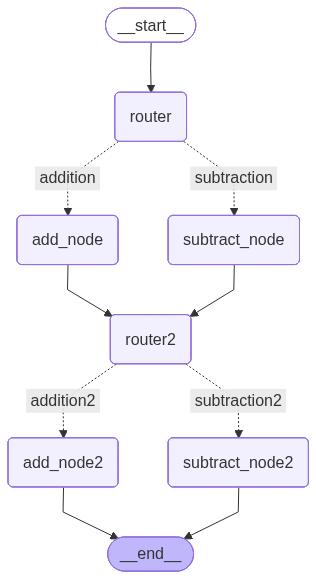

In [16]:
from  IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
initial_state_1 = AgentState(num1=10, num2=5, operation1='+', num3=20, num4=10, operation2='-')
print(app.invoke(initial_state_1))  # Should print the state with result 15


{'num1': 10, 'num2': 5, 'operation1': '+', 'result1': 15, 'num3': 20, 'num4': 10, 'operation2': '-', 'result2': 10}
